# Depuración y preparación del dataset

## Objetivos 

En esta segunda sesión se busca:

1. Revisar con más detalle la codificación de algunas variables categóricas.
2. Detectar categorías atípicas o no documentadas.
3. Recodificar variables para facilitar su interpretación y modelado.
4. Construir un dataset analítico limpio.
5. Separar la variable objetivo y las variables predictoras.
6. Dejar preparado el conjunto de datos para la etapa de modelado.

## Contexto

En la primera sesión se realizó una exploración inicial del dataset y se identificaron algunas variables con categorías no estándar, especialmente en `EDUCATION` y `MARRIAGE`.

Antes de construir modelos predictivos, es importante revisar estas variables y preparar una versión del conjunto de datos que sea coherente, interpretable y adecuada para análisis posteriores.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path


In [27]:
DATA_PATH = "default of credit card clients.xls"

df = pd.read_excel(DATA_PATH, header=1)
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,0,0,188948,192815,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,0,0,1683,1828,3502,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,0,0,3565,3356,2758,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,0,-1,-1645,78379,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [28]:
# Renombrado de columnas
df = df.rename(columns={
    "default payment next month": "default_next_month"
})

In [29]:
## Revisión general del conjunto de datos
print("Dimensiones:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

Dimensiones: (30000, 25)

Columnas:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default_next_month']


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID                  30000 non-null  int64
 1   LIMIT_BAL           30000 non-null  int64
 2   SEX                 30000 non-null  int64
 3   EDUCATION           30000 non-null  int64
 4   MARRIAGE            30000 non-null  int64
 5   AGE                 30000 non-null  int64
 6   PAY_0               30000 non-null  int64
 7   PAY_2               30000 non-null  int64
 8   PAY_3               30000 non-null  int64
 9   PAY_4               30000 non-null  int64
 10  PAY_5               30000 non-null  int64
 11  PAY_6               30000 non-null  int64
 12  BILL_AMT1           30000 non-null  int64
 13  BILL_AMT2           30000 non-null  int64
 14  BILL_AMT3           30000 non-null  int64
 15  BILL_AMT4           30000 non-null  int64
 16  BILL_AMT5           30000 non-null  int64
 17  BILL

### Revisión de variables categóricas y ordinales

En esta sección se revisan las categorías observadas en algunas variables clave para identificar posibles codificaciones atípicas o no documentadas.

In [31]:
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
for col in cat_cols:
    print(f"\nDistribución de {col}")
    print(df[col].value_counts(dropna=False).sort_index())


Distribución de SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

Distribución de EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Distribución de MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [32]:
ord_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
for col in ord_cols:
    print(f"\nDistribución de {col}")
    print(df[col].value_counts(dropna=False).sort_index())


Distribución de PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

Distribución de PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

Distribución de PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

Distribución de PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

Distribución de PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

Distribución de PAY_6
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766


### Observación sobre categorías no estándar

En `EDUCATION` aparecen categorías como `0`, `5` y `6`, y en `MARRIAGE` aparece la categoría `0`, las cuales no forman parte de la codificación principal documentada.

Por ello, es razonable recodificarlas para evitar interpretaciones ambiguas y facilitar el análisis posterior.

In [33]:
df_clean = df.copy()

### Recodificación de `EDUCATION`

La documentación principal considera las categorías:

- `1 = posgrado`
- `2 = universitarios`
- `3 = bachillerato`
- `4 = otros`

Como en la base aparecen también las categorías `0`, `5` y `6`, se agruparán dentro de la categoría `4 = otros`.

In [34]:
df_clean["EDUCATION"] = df_clean["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

In [35]:
df_clean["EDUCATION"].value_counts().sort_index()

EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

## Recodificación de `MARRIAGE`

La documentación principal considera:

- `1 = casado`
- `2 = soltero`
- `3 = otros`

Como aparece la categoría `0`, ésta se agrupará dentro de `3 = otros`.

In [36]:
df_clean["MARRIAGE"] = df_clean["MARRIAGE"].replace({
    0: 3
})

In [37]:
df_clean["MARRIAGE"].value_counts().sort_index()

MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

### Etiquetas descriptivas para variables categóricas

Se crean versiones etiquetadas de algunas variables para facilitar la interpretación en tablas y gráficas.

In [38]:
sex_map = {1: "Masculino", 2: "Femenino"}
education_map = {
    1: "Posgrado",
    2: "Universidad",
    3: "Bachillerato",
    4: "Otros"
}
marriage_map = {
    1: "Casado",
    2: "Soltero",
    3: "Otros"
}

df_clean["SEX_LABEL"] = df_clean["SEX"].map(sex_map)
df_clean["EDUCATION_LABEL"] = df_clean["EDUCATION"].map(education_map)
df_clean["MARRIAGE_LABEL"] = df_clean["MARRIAGE"].map(marriage_map)

In [39]:
df_clean[["SEX", "SEX_LABEL", "EDUCATION", "EDUCATION_LABEL", "MARRIAGE", "MARRIAGE_LABEL"]].head(10)

,SEX,SEX_LABEL,EDUCATION,EDUCATION_LABEL,MARRIAGE,MARRIAGE_LABEL
0,2,Femenino,2,Universidad,1,Casado
1,2,Femenino,2,Universidad,2,Soltero
2,2,Femenino,2,Universidad,2,Soltero
3,2,Femenino,2,Universidad,1,Casado
4,1,Masculino,2,Universidad,1,Casado
5,1,Masculino,1,Posgrado,2,Soltero
6,1,Masculino,1,Posgrado,2,Soltero
7,2,Femenino,2,Universidad,2,Soltero
8,2,Femenino,3,Bachillerato,1,Casado
9,1,Masculino,3,Bachillerato,2,Soltero


In [40]:
## Verificación posterior a la recodificación
missing = df_clean.isna().sum().to_frame("missing_count")
missing["missing_pct"] = 100 * missing["missing_count"] / len(df_clean)
missing.sort_values("missing_count", ascending=False).head(10)

,missing_count,missing_pct
ID,0,0.0000
LIMIT_BAL,0,0.0000
EDUCATION_LABEL,0,0.0000
SEX_LABEL,0,0.0000
default_next_month,0,0.0000
PAY_AMT6,0,0.0000
PAY_AMT5,0,0.0000
PAY_AMT4,0,0.0000
PAY_AMT3,0,0.0000
PAY_AMT2,0,0.0000


In [41]:
print("Duplicados:", df_clean.duplicated().sum())

Duplicados: 0


### Revisión preliminar de variables numéricas

En esta etapa sólo se revisan rangos y estadísticas resumidas de algunas variables numéricas para detectar valores inusuales o escalas muy distintas.

In [42]:
num_cols = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

df_clean[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,"30,000.0000","167,484.3227","129,747.6616","10,000.0000","50,000.0000","140,000.0000","240,000.0000","1,000,000.0000"
AGE,"30,000.0000",35.4855,9.2179,21.0000,28.0000,34.0000,41.0000,79.0000
BILL_AMT1,"30,000.0000","51,223.3309","73,635.8606","-165,580.0000","3,558.7500","22,381.5000","67,091.0000","964,511.0000"
BILL_AMT2,"30,000.0000","49,179.0752","71,173.7688","-69,777.0000","2,984.7500","21,200.0000","64,006.2500","983,931.0000"
BILL_AMT3,"30,000.0000","47,013.1548","69,349.3874","-157,264.0000","2,666.2500","20,088.5000","60,164.7500","1,664,089.0000"
BILL_AMT4,"30,000.0000","43,262.9490","64,332.8561","-170,000.0000","2,326.7500","19,052.0000","54,506.0000","891,586.0000"
BILL_AMT5,"30,000.0000","40,311.4010","60,797.1558","-81,334.0000","1,763.0000","18,104.5000","50,190.5000","927,171.0000"
BILL_AMT6,"30,000.0000","38,871.7604","59,554.1075","-339,603.0000","1,256.0000","17,071.0000","49,198.2500","961,664.0000"
PAY_AMT1,"30,000.0000","5,663.5805","16,563.2804",0.0000,"1,000.0000","2,100.0000","5,006.0000","873,552.0000"
PAY_AMT2,"30,000.0000","5,921.1635","23,040.8704",0.0000,833.0000,"2,009.0000","5,000.0000","1,684,259.0000"


### Distribuciones de variables numéricas seleccionadas

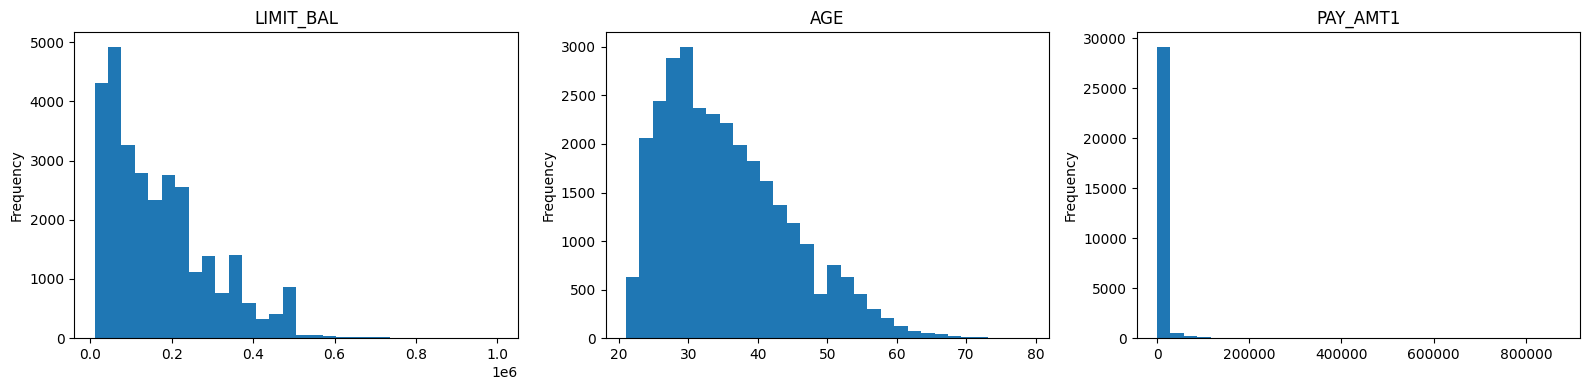

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_clean["LIMIT_BAL"].plot(kind="hist", bins=30, ax=axes[0], title="LIMIT_BAL")
df_clean["AGE"].plot(kind="hist", bins=30, ax=axes[1], title="AGE")
df_clean["PAY_AMT1"].plot(kind="hist", bins=30, ax=axes[2], title="PAY_AMT1")

plt.tight_layout()
plt.show()

### Construcción de grupos de edad

Se definen grupos de edad para facilitar análisis descriptivos y posibles comparaciones posteriores.

In [44]:
bins = [20, 30, 40, 50, 60, 80]
labels = ["20-29", "30-39", "40-49", "50-59", "60+"]

df_clean["AGE_GROUP"] = pd.cut(df_clean["AGE"], bins=bins, labels=labels, right=False)
df_clean["AGE_GROUP"].value_counts(dropna=False).sort_index()

AGE_GROUP
20-29     9618
30-39    11238
40-49     6464
50-59     2341
60+        339
Name: count, dtype: int64

### Clasificación de variables por tipo

Antes de modelar, conviene distinguir qué variables son:

- categóricas nominales,
- ordinales,
- numéricas continuas o discretas.

Esta clasificación ayuda a decidir qué transformaciones aplicar y qué métodos estadísticos son más apropiados.

In [45]:
variable_types = pd.DataFrame({
    "variable": [
        "ID", "LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
        "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
        "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
        "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
        "default_next_month"
    ],
    "tipo_sugerido": [
        "Identificador", "Numérica", "Categórica nominal", "Categórica",
        "Categórica nominal", "Numérica",
        "Ordinal", "Ordinal", "Ordinal", "Ordinal", "Ordinal", "Ordinal",
        "Numérica", "Numérica", "Numérica", "Numérica", "Numérica", "Numérica",
        "Numérica", "Numérica", "Numérica", "Numérica", "Numérica", "Numérica",
        "Objetivo binaria"
    ]
})

variable_types

,variable,tipo_sugerido
0,ID,Identificador
1,LIMIT_BAL,Numérica
2,SEX,Categórica nominal
3,EDUCATION,Categórica
4,MARRIAGE,Categórica nominal
5,AGE,Numérica
6,PAY_0,Ordinal
7,PAY_2,Ordinal
8,PAY_3,Ordinal
9,PAY_4,Ordinal


### Selección preliminar de variables para modelado

La variable `ID` funciona únicamente como identificador, por lo que no debe utilizarse como predictor.

In [46]:
df_model = df_clean.drop(columns=["ID", "SEX_LABEL", "EDUCATION_LABEL", "MARRIAGE_LABEL"])
df_model.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,AGE_GROUP
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,20-29
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,20-29
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,30-39
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,30-39
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,50-59


### Separación de predictores y variable objetivo

Se define:

- `X`: matriz de variables predictoras
- `y`: variable objetivo de incumplimiento

In [47]:
X = df_model.drop(columns=["default_next_month"])
y = df_model["default_next_month"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (30000, 24)
Dimensiones de y: (30000,)


### Guardado del dataset limpio

Se guarda una versión depurada del conjunto de datos para utilizarla en sesiones posteriores.

In [48]:
df_clean.to_csv("default_credit_clean.csv", index=False)
print("Archivo guardado como: default_credit_clean.csv")

Archivo guardado como: default_credit_clean.csv


## Conclusiones de esta sesión

En esta sesión se realizó una depuración inicial del conjunto de datos con el objetivo de preparar una versión más adecuada para análisis posteriores.

En particular:

1. Se revisaron las categorías observadas en variables categóricas y ordinales.
2. Se identificaron categorías no estándar en `EDUCATION` y `MARRIAGE`.
3. Se recodificaron estas categorías para obtener variables más consistentes.
4. Se construyeron etiquetas descriptivas para facilitar la interpretación.
5. Se generó una versión limpia del dataset y se separaron las variables predictoras de la variable objetivo.

Con esto, el conjunto de datos queda listo para la siguiente etapa: construcción de un primer modelo baseline de clasificación.

### Tarea 3. Clasificación de variables

Elaborar una tabla donde se clasifique cada variable del dataset en una de las siguientes categorías:

- identificador,
- numérica,
- categórica nominal,
- ordinal,
- variable objetivo binaria.

### Entregable

Entregar un notebook que incluya:

- tablas,
- gráficas,
- interpretaciones breves,
- y una conclusión final de media a una cuartilla donde se resuma:

  - qué se observó en las variables `PAY_*`,
  - qué tipo de correlación sería más adecuado según el tipo de variable,
  - y por qué es importante distinguir entre variables numéricas, categóricas y ordinales antes de modelar.